# 03 — Classification
## DENTEX Dataset — Disease Classification with ResNet50, DenseNet121, and ViT-B/16

**Student:** Shree Ramji | ec25075@qmul.ac.uk  
**Dataset:** DENTEX (MICCAI 2023)  

### Objectives:
1. Train ResNet50 (CNN baseline) on DENTEX disease classification
2. Train DenseNet121 (CNN improved) on DENTEX disease classification
3. Train ViT-B/16 (Transformer) on DENTEX disease classification
4. Evaluate all three models — Accuracy, F1, ROC-AUC, Confusion Matrix
5. Compare CNN vs Transformer performance for dissertation

### Models:
| Model | Type | Pretrained | Parameters |
|---|---|---|---|
| ResNet50 | CNN | ImageNet | ~25M |
| DenseNet121 | CNN | ImageNet | ~8M |
| ViT-B/16 | Transformer | ImageNet-21k | ~86M |

### Key decisions:
- ImageFolder used — images already sorted into class subfolders in preprocessing
- Class weights applied to CrossEntropyLoss — addresses Periapical imbalance (5.58x)
- Augmentation applied on-the-fly in train transform — not pre-saved
- W&B used for experiment tracking — all runs logged for dissertation results chapter
- Best model saved by validation F1 (not accuracy) — better metric for imbalanced data

## 1. Install Dependencies

In [1]:
!pip install timm wandb scikit-learn torchmetrics -q
print("✓ Dependencies installed")

✓ Dependencies installed


## 2. Seed and Imports

In [2]:
import torch
import numpy as np
import random
import os
import copy
import json
from pathlib import Path
os.environ['WANDB_MODE'] = 'online'
os.environ['WANDB_NOTEBOOK_NAME'] = '03_classification.ipynb'


import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torch.cuda.amp import autocast, GradScaler
import timm
import torchvision.transforms as T

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
scaler = GradScaler()  # mixed precision scaler — shared across all models

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"Device  : {device}")
print(f"AMP     : enabled ✓")

[HAMI-core Msg(497:140128384331072:libvgpu.c:839)]: Initializing.....
[HAMI-core Warn(497:140128384331072:multiprocess_memory_limit.c:548)]: Kick dead proc 406
/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch : 2.9.1+cu128
CUDA    : True
GPU     : NVIDIA A100 80GB PCIe
Device  : cuda
AMP     : enabled ✓


[HAMI-core Msg(497:140128384331072:libvgpu.c:855)]: Initialized


## 3. Define Paths and Constants

In [3]:
# Paths — CNN processed images from preprocessing notebook
cnn_root   = Path("./data/processed/cnn")
model_dir  = Path("./models")
output_dir = Path("./outputs/classification")

model_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

# Disease classes — must match ImageFolder alphabetical order
# ImageFolder sorts class folders alphabetically:
# Caries=0, Deep_Caries=1, Impacted=2, Periapical_Lesion=3
CLASS_NAMES = ['Caries', 'Deep_Caries', 'Impacted', 'Periapical_Lesion']
NUM_CLASSES  = 4

# ImageNet normalisation — required for all pretrained models
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training hyperparameters
CNN_SIZE    = 224   # ResNet50, DenseNet121
VIT_SIZE    = 224   # ViT-B/16

print(f"CNN root   : {cnn_root}")
print(f"Model dir  : {model_dir}")
print(f"Output dir : {output_dir}")
print(f"\nClass mapping (ImageFolder alphabetical order):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

CNN root   : data/processed/cnn
Model dir  : models
Output dir : outputs/classification

Class mapping (ImageFolder alphabetical order):
  0: Caries
  1: Deep_Caries
  2: Impacted
  3: Periapical_Lesion


## 4. Data Loading
Using PyTorch ImageFolder — reads images directly from class subfolders.
Transforms applied on-the-fly:
- Train: resize → random flip → brightness/contrast → rotate → normalise
- Val/Test: resize → normalise only (no augmentation — fair evaluation)

In [4]:
# Training transforms
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.RandomRotation(degrees=10),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Val/test transforms — no augmentation
eval_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Datasets
train_dataset = datasets.ImageFolder(root=cnn_root / 'train', transform=train_transform)
val_dataset   = datasets.ImageFolder(root=cnn_root / 'val',   transform=eval_transform)
test_dataset  = datasets.ImageFolder(root=cnn_root / 'test',  transform=eval_transform,
                                      allow_empty=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train : {len(train_dataset)} images | {len(train_loader)} batches")
print(f"Val   : {len(val_dataset)} images | {len(val_loader)} batches")
print(f"Test  : {len(test_dataset)} images | {len(test_loader)} batches")
print(f"\nImageFolder class → index mapping:")
print(f"  {train_dataset.class_to_idx}")

Train : 678 images | 22 batches
Val   : 46 images | 2 batches
Test  : 242 images | 8 batches

ImageFolder class → index mapping:
  {'Caries': 0, 'Deep_Caries': 1, 'Impacted': 2, 'Periapical_Lesion': 3}


In [5]:
# Verify one batch loads correctly
images, labels = next(iter(train_loader))
print(f"Batch shape  : {images.shape}")   # [32, 3, 224, 224]
print(f"Labels shape : {labels.shape}")   # [32]
print(f"Label values : {labels.unique()}")
print(f"Pixel range  : [{images.min():.2f}, {images.max():.2f}]")  # normalised — not 0-1

# Verify class distribution per split
print("\nClass distribution:")
print(f"{'Class':<25} {'Train':>8} {'Val':>6} {'Test':>6}")
print("-" * 48)
for idx, cls_name in enumerate(CLASS_NAMES):
    t  = sum(1 for _, l in train_dataset if l == idx)
    v  = sum(1 for _, l in val_dataset   if l == idx)
    te = sum(1 for _, l in test_dataset  if l == idx)
    print(f"  {cls_name:<23} {t:>8} {v:>6} {te:>6}")

Batch shape  : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Label values : tensor([0, 1, 2])
Pixel range  : [-2.12, 2.64]

Class distribution:
Class                        Train    Val   Test
------------------------------------------------
  Caries                       476     27    163
  Deep_Caries                   70      8      0
  Impacted                     116      9     42
  Periapical_Lesion             16      2     37


## 5. Class Weights
Inverse frequency weights computed from training annotation counts.
Applied to CrossEntropyLoss to penalise misclassification of minority classes.
Periapical Lesion (only 16 train images) gets 5.58x more penalty than Caries.

In [6]:
# Class weights from preprocessing notebook (inverse frequency of annotations)
# Order matches ImageFolder alphabetical: Caries, Deep_Caries, Impacted, Periapical_Lesion
# Annotation counts: Caries=2189, Deep_Caries=578, Impacted=604, Periapical_Lesion=158

class_weights = torch.tensor([
    0.4030,   # Caries           — majority, penalised least
    1.5264,   # Deep_Caries
    1.4607,   # Impacted
    5.5839    # Periapical_Lesion — minority, penalised most
], dtype=torch.float).to(device)

print("Class weights (CrossEntropyLoss):")
for name, w in zip(CLASS_NAMES, class_weights):
    print(f"  {name:<25} {w:.4f}")

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f"\nLoss function: CrossEntropyLoss with class weights ✓")

Class weights (CrossEntropyLoss):
  Caries                    0.4030
  Deep_Caries               1.5264
  Impacted                  1.4607
  Periapical_Lesion         5.5839

Loss function: CrossEntropyLoss with class weights ✓


## 6. Training and Evaluation Utilities
Reusable functions used for all three models.
- `train_one_epoch` — one forward/backward pass over train set
- `evaluate` — runs model on a dataloader, returns all metrics
- `plot_curves` — loss and accuracy curves from training history
- `plot_confusion_matrix` — confusion matrix heatmap

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler):
    """
    One training epoch with:
    - Mixed precision (autocast) — 2x faster, half memory on GPU
    - Gradient clipping (max_norm=1.0) — prevents exploding gradients (critical for ViT)
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # Mixed precision forward pass
        with autocast():
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

        # Scaled backward + gradient clipping
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        _, predicted  = outputs.max(1)
        correct      += predicted.eq(labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, correct / total

print("train_one_epoch() with AMP + grad clipping defined ✓")

train_one_epoch() with AMP + grad clipping defined ✓


In [8]:
def evaluate(model, loader, criterion, device, class_names):
    """
    Evaluate model on a dataloader.
    Returns dict with macro + per-class metrics and raw predictions.
    ROC-AUC computed only on classes present in labels (handles missing test classes).
    """
    model.eval()
    running_loss = 0.0
    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            probs   = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            running_loss += loss.item() * images.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    avg_loss  = running_loss / len(loader.dataset)
    accuracy  = accuracy_score(all_labels, all_preds)

    # Macro metrics — zero_division=0 handles missing classes (e.g. Deep_Caries in test)
    f1        = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall    = recall_score(all_labels, all_preds, average='macro', zero_division=0)

    # Per-class F1 — critical for dissertation minority class analysis
    f1_per_class = f1_score(
        all_labels, all_preds, average=None,
        labels=list(range(len(class_names))), zero_division=0
    )

    # ROC-AUC — only on classes present in labels (avoids nan from missing Deep_Caries test)
    present_classes = np.unique(all_labels).astype(int)
    try:
        if len(present_classes) >= 2:
            probs_subset = all_probs[:, present_classes]
            # Re-normalise rows to sum to 1 after dropping missing class column
            probs_subset = probs_subset / probs_subset.sum(axis=1, keepdims=True)
            roc_auc = roc_auc_score(
                all_labels,
                probs_subset,
                multi_class='ovr',
                average='macro',
                labels=present_classes
            )
        else:
            roc_auc = float('nan')
    except Exception as e:
        print(f"ROC-AUC error: {e}")
        roc_auc = float('nan')

    return {
        'loss'        : avg_loss,
        'accuracy'    : accuracy,
        'f1'          : f1,
        'f1_per_class': f1_per_class,   # array: one F1 per class
        'precision'   : precision,
        'recall'      : recall,
        'roc_auc'     : roc_auc,
        'preds'       : all_preds,
        'labels'      : all_labels,
        'probs'       : all_probs
    }

print("evaluate() defined ✓")

evaluate() defined ✓


In [9]:
def count_params(model):
    """Count total and trainable parameters."""
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def print_model_size(model, model_name):
    total, trainable = count_params(model)
    print(f"{model_name:<20} Total: {total:>12,}   Trainable: {trainable:>12,}")

print("count_params() defined ✓")
print("(Will print model size comparison after all 3 models built)")

count_params() defined ✓
(Will print model size comparison after all 3 models built)


In [10]:
def plot_curves(history, model_name, save_dir):
    """Plot train/val loss and accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    epochs = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0].plot(epochs, history['train_loss'], label='Train', marker='o', markersize=3)
    axes[0].plot(epochs, history['val_loss'],   label='Val',   marker='o', markersize=3)
    axes[0].set_title(f'{model_name} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history['train_acc'], label='Train', marker='o', markersize=3)
    axes[1].plot(epochs, history['val_acc'],   label='Val',   marker='o', markersize=3)
    axes[1].set_title(f'{model_name} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = save_dir / f'{model_name}_curves.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {save_path}")


def plot_confusion_matrix(preds, labels, class_names, model_name, save_dir):
    """Plot normalised confusion matrix."""
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # normalise by row

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, vmin=0, vmax=1)
    ax.set_title(f'{model_name} — Confusion Matrix (normalised)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    save_path = save_dir / f'{model_name}_confusion_matrix.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {save_path}")


print("Utility functions defined ✓")

Utility functions defined ✓


## 7. Model 1 — ResNet50 (CNN Baseline)
ResNet50 pretrained on ImageNet. Final FC layer replaced for 4-class DENTEX classification.

Fine-tuning strategy:
- Phase 1 (epochs 1–5): backbone frozen, head only trained, lr=1e-3
- Phase 2 (epochs 6+): all layers unfrozen, full fine-tune, lr=1e-5
- Scheduler: ReduceLROnPlateau on val loss (factor=0.5, patience=5)
- Early stopping: patience=10 epochs on val F1
- Save best model by validation F1 (not accuracy — imbalanced classes)

In [11]:
def build_resnet50(num_classes, device):
    """
    Load ResNet50 with ImageNet pretrained weights.
    Replace final FC layer for num_classes output.
    All layers unfrozen for full fine-tuning.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Replace final fully connected layer
    # ResNet50 final layer: Linear(2048 → 1000) → replace with Linear(2048 → 4)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    model = model.to(device)
    return model

resnet50 = build_resnet50(NUM_CLASSES, device)

# Print model summary
total_params     = sum(p.numel() for p in resnet50.parameters())
trainable_params = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)
print(f"ResNet50 built ✓")
print(f"  Total params     : {total_params:,}")
print(f"  Trainable params : {trainable_params:,}")
print(f"  Final layer      : {resnet50.fc}")

ResNet50 built ✓
  Total params     : 23,516,228
  Trainable params : 23,516,228
  Final layer      : Linear(in_features=2048, out_features=4, bias=True)


In [12]:
def train_model(model, model_name, train_loader, val_loader,
                criterion, device, class_names, wandb_run,
                epochs=50, lr_head=1e-3, lr_finetune=1e-5,
                freeze_epochs=5, patience=10,
                save_dir=model_dir):
    """
    Two-phase training with:
    - Phase 1: frozen backbone, head only, lr=lr_head
    - Phase 2: full fine-tune, lr=lr_finetune
    - Early stopping on val F1 (patience resets at Phase 2)
    - ReduceLROnPlateau scheduler
    - AMP mixed precision via global scaler
    - W&B run passed in (not created inside — avoids zombie runs)
    """

    # Phase 1: freeze backbone, train head only
    for name, param in model.named_parameters():
        # Only unfreeze final classification head
        # ViT: 'head' — but NOT 'mlp.fc1/fc2' inside blocks
        if name in ('head.weight', 'head.bias',
                    'fc.weight', 'fc.bias',
                    'classifier.weight', 'classifier.bias'):
            param.requires_grad = True
        else:
            param.requires_grad = False

    # Verify freeze worked
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_p   = sum(p.numel() for p in model.parameters())
    print(f"Phase 1 — Trainable: {trainable:,} / {total_p:,} ({100*trainable/total_p:.1f}%)")
    if trainable / total_p > 0.5:
        print("  ⚠️ WARNING: >50% params trainable in Phase 1 — freeze may not have worked")

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_head, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc' : [], 'val_acc' : [],
        'val_f1'    : []
    }

    best_val_f1       = 0.0
    best_model_wts    = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    print(f"\nTraining {model_name} — up to {epochs} epochs")
    print(f"  Phase 1: epochs 1–{freeze_epochs}  | backbone frozen | lr={lr_head}")
    print(f"  Phase 2: epochs {freeze_epochs+1}+   | full fine-tune  | lr={lr_finetune}")
    print(f"  Early stopping patience: {patience}\n")
    print(f"{'Epoch':>6} {'Phase':>8} {'TrainLoss':>10} {'TrainAcc':>9} "
          f"{'ValLoss':>8} {'ValAcc':>7} {'ValF1':>7}")
    print("-" * 62)

    for epoch in range(1, epochs + 1):

        # --- Switch to Phase 2 ---
        if epoch == freeze_epochs + 1:
            print(f"\n  → Phase 2: unfreezing all layers | lr={lr_finetune}")
            for param in model.parameters():
                param.requires_grad = True
            trainable2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"  Trainable: {trainable2:,} / {total_p:,} ({100*trainable2/total_p:.1f}%)\n")

            optimizer = optim.Adam(
                model.parameters(), lr=lr_finetune, weight_decay=1e-4
            )
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=5
            )
            # Reset patience counter — Phase 2 gets fresh start
            epochs_no_improve = 0
            best_val_f1       = 0.0

        phase = "frozen" if epoch <= freeze_epochs else "finetune"

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device, scaler
        )
        val_metrics = evaluate(model, val_loader, criterion, device, class_names)
        val_loss = val_metrics['loss']
        val_acc  = val_metrics['accuracy']
        val_f1   = val_metrics['f1']

        scheduler.step(val_loss)

        # Log to W&B
        wandb_run.log({
            "epoch"      : epoch,
            "phase"      : phase,
            "train_loss" : train_loss,
            "train_acc"  : train_acc,
            "val_loss"   : val_loss,
            "val_acc"    : val_acc,
            "val_f1"     : val_f1,
            "val_roc_auc": val_metrics['roc_auc'],
            "lr"         : optimizer.param_groups[0]['lr']
        })

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        # Save best by val F1
        improved = ""
        if val_f1 > best_val_f1:
            best_val_f1    = val_f1
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_dir / f"{model_name}_best.pt")
            epochs_no_improve = 0
            improved = " ← best"
        else:
            epochs_no_improve += 1

        print(f"{epoch:>6} {phase:>8} {train_loss:>10.4f} {train_acc:>9.4f} "
              f"{val_loss:>8.4f} {val_acc:>7.4f} {val_f1:>7.4f}{improved}")

        # Early stopping
        if epochs_no_improve >= patience:
            print(f"\n  Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_model_wts)
    print(f"\n✓ Done. Best Val F1: {best_val_f1:.4f}")
    print(f"✓ Saved: {save_dir / f'{model_name}_best.pt'}")
    return model, history

print("train_model() defined ✓")

train_model() defined ✓


In [13]:
# W&B init outside train_model — avoids zombie runs on crash/retry
run = wandb.init(
    project="dental-disease-detection",
    name="ResNet50_lrH1e3_lrF1e5_batch32_freeze5_ep50",
    config={
        "model"         : "ResNet50",
        "epochs"        : 50,
        "lr_head"       : 1e-3,
        "lr_finetune"   : 1e-5,
        "freeze_epochs" : 5,
        "batch_size"    : 32,
        "optimizer"     : "Adam",
        "weight_decay"  : 1e-4,
        "scheduler"     : "ReduceLROnPlateau(factor=0.5, patience=5)",
        "early_stopping": 10,
        "amp"           : True,
        "grad_clip"     : 1.0,
        "loss"          : "CrossEntropyLoss (weighted)",
        "dataset"       : "DENTEX"
    }
)

resnet50, resnet50_history = train_model(
    model         = resnet50,
    model_name    = "resnet50",
    train_loader  = train_loader,
    val_loader    = val_loader,
    criterion     = criterion,
    device        = device,
    class_names   = CLASS_NAMES,
    wandb_run     = run,
    epochs        = 50,
    lr_head       = 1e-3,
    lr_finetune   = 1e-5,
    freeze_epochs = 5,
    patience      = 10
)

wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.
wandb: Currently logged in as: shree-cloudarcade (shree-cloudarcade-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Phase 1 — Trainable: 8,196 / 23,516,228 (0.0%)

Training resnet50 — up to 50 epochs
  Phase 1: epochs 1–5  | backbone frozen | lr=0.001
  Phase 2: epochs 6+   | full fine-tune  | lr=1e-05
  Early stopping patience: 10

 Epoch    Phase  TrainLoss  TrainAcc  ValLoss  ValAcc   ValF1
--------------------------------------------------------------
     1   frozen     1.4175    0.3879   1.4339  0.4348  0.2282 ← best
     2   frozen     1.3227    0.5133   1.4706  0.1957  0.0956
     3   frozen     1.3404    0.5988   1.6900  0.1739  0.0876
     4   frozen     1.2425    0.4410   1.6186  0.6087  0.2653 ← best
     5   frozen     1.4006    0.4882   1.6340  0.3261  0.1811

  → Phase 2: unfreezing all layers | lr=1e-05
  Trainable: 23,516,228 / 23,516,228 (100.0%)

     6 finetune     1.2424    0.5221   1.6920  0.3261  0.1828 ← best
     7 finetune     1.2001    0.5501   1.5359  0.3913  0.2010 ← best
     8 finetune     1.1365    0.6047   1.4857  0.4783  0.2262 ← best
     9 finetune     1.0489    0

epoch,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
lr,█████▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▃▄▂▃▃▃▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇██
train_loss,█▇▇▇█▇▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁
val_acc,▅▁▁█▃▃▅▆▆▇▇▇▇█▇▇▇██▇▇▇▇▇
val_f1,▃▁▁▄▃▃▃▃▄▄▄▅▅█▇▇▆▆▆▅▆▆▆▆
val_loss,▄▄█▇▇█▆▅▅▄▂▂▂▂▁▁▁▂▂▂▁▂▃▂
val_roc_auc,▅▅▂▁▁▃▃▄▃▅▇▆▆▇▇█▇▇▇▇█▇▆▇
epoch,24
lr,1e-05
phase,finetune


ResNet50 — Test Set Results
  Accuracy  : 0.5826
  F1 macro  : 0.3209
  Precision : 0.3446
  Recall    : 0.3255
  ROC-AUC   : 0.6851

Per-class F1:
  Caries                    0.7156
  Deep_Caries               0.0000
  Impacted                  0.4082
  Periapical_Lesion         0.1600

Full classification report:
                   precision    recall  f1-score   support

           Caries       0.71      0.72      0.72       163
      Deep_Caries       0.00      0.00      0.00         0
         Impacted       0.36      0.48      0.41        42
Periapical_Lesion       0.31      0.11      0.16        37

         accuracy                           0.58       242
        macro avg       0.34      0.33      0.32       242
     weighted avg       0.59      0.58      0.58       242



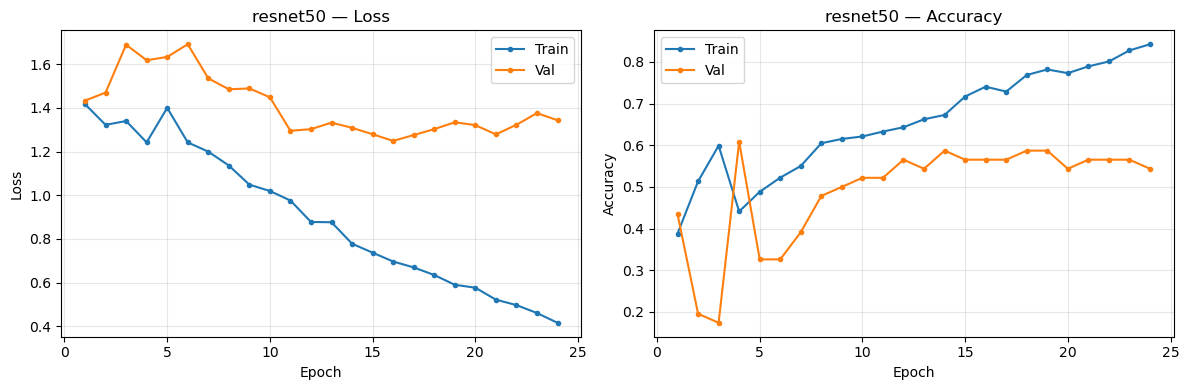

✓ Saved: outputs/classification/resnet50_curves.png


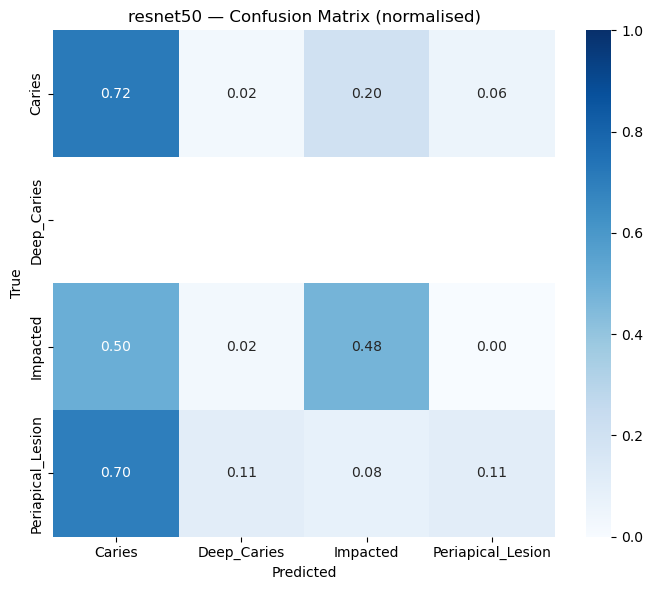

✓ Saved: outputs/classification/resnet50_confusion_matrix.png


In [14]:
# Load best saved weights and evaluate on test set
resnet50.load_state_dict(torch.load(model_dir / "resnet50_best.pt", map_location=device))
test_metrics_resnet50 = evaluate(resnet50, test_loader, criterion, device, CLASS_NAMES)

print("=" * 55)
print("ResNet50 — Test Set Results")
print("=" * 55)
print(f"  Accuracy  : {test_metrics_resnet50['accuracy']:.4f}")
print(f"  F1 macro  : {test_metrics_resnet50['f1']:.4f}")
print(f"  Precision : {test_metrics_resnet50['precision']:.4f}")
print(f"  Recall    : {test_metrics_resnet50['recall']:.4f}")
print(f"  ROC-AUC   : {test_metrics_resnet50['roc_auc']:.4f}")

print("\nPer-class F1:")
for name, f1 in zip(CLASS_NAMES, test_metrics_resnet50['f1_per_class']):
    print(f"  {name:<25} {f1:.4f}")

print("\nFull classification report:")
print(classification_report(
    test_metrics_resnet50['labels'],
    test_metrics_resnet50['preds'],
    target_names=CLASS_NAMES,
    zero_division=0
))

plot_curves(resnet50_history, "resnet50", output_dir)
plot_confusion_matrix(
    test_metrics_resnet50['preds'],
    test_metrics_resnet50['labels'],
    CLASS_NAMES, "resnet50", output_dir
)

## 8. Model 2 — DenseNet121
DenseNet121 pretrained on ImageNet. Final classifier layer replaced for 4-class DENTEX classification.

DenseNet121 vs ResNet50:
- Fewer parameters (~8M vs ~25M) — less overfitting risk on small dataset
- Dense connections — each layer receives feature maps from ALL previous layers
- Better gradient flow — helps with small datasets
- Final layer: model.classifier (not model.fc like ResNet50)

Same two-phase training strategy as ResNet50.

In [15]:
def build_densenet121(num_classes, device):
    """
    Load DenseNet121 with ImageNet pretrained weights.
    Replace final classifier layer for num_classes output.
    DenseNet121 final layer: model.classifier — Linear(1024 → 1000)
    """
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

    # Replace final classifier
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)

    model = model.to(device)
    return model

set_seed(42)
densenet121 = build_densenet121(NUM_CLASSES, device)

total_params     = sum(p.numel() for p in densenet121.parameters())
trainable_params = sum(p.numel() for p in densenet121.parameters() if p.requires_grad)
print(f"DenseNet121 built ✓")
print(f"  Total params     : {total_params:,}")
print(f"  Trainable params : {trainable_params:,}")
print(f"  Final layer      : {densenet121.classifier}")

DenseNet121 built ✓
  Total params     : 6,957,956
  Trainable params : 6,957,956
  Final layer      : Linear(in_features=1024, out_features=4, bias=True)


In [16]:
run = wandb.init(
    project="dental-disease-detection",
    name="DenseNet121_lrH1e3_lrF1e5_batch32_freeze5_ep50",
    config={
        "model"         : "DenseNet121",
        "epochs"        : 50,
        "lr_head"       : 1e-3,
        "lr_finetune"   : 1e-5,
        "freeze_epochs" : 5,
        "batch_size"    : 32,
        "optimizer"     : "Adam",
        "weight_decay"  : 1e-4,
        "scheduler"     : "ReduceLROnPlateau(factor=0.5, patience=5)",
        "early_stopping": 10,
        "amp"           : True,
        "grad_clip"     : 1.0,
        "loss"          : "CrossEntropyLoss (weighted)",
        "dataset"       : "DENTEX"
    }
)
set_seed(42)
densenet121, densenet121_history = train_model(
    model         = densenet121,
    model_name    = "densenet121",
    train_loader  = train_loader,
    val_loader    = val_loader,
    criterion     = criterion,
    device        = device,
    class_names   = CLASS_NAMES,
    wandb_run     = run,
    epochs        = 50,
    lr_head       = 1e-3,
    lr_finetune   = 1e-5,
    freeze_epochs = 5,
    patience      = 10
)

wandb.finish()

Phase 1 — Trainable: 4,100 / 6,957,956 (0.1%)

Training densenet121 — up to 50 epochs
  Phase 1: epochs 1–5  | backbone frozen | lr=0.001
  Phase 2: epochs 6+   | full fine-tune  | lr=1e-05
  Early stopping patience: 10

 Epoch    Phase  TrainLoss  TrainAcc  ValLoss  ValAcc   ValF1
--------------------------------------------------------------
     1   frozen     1.4319    0.5029   1.6321  0.1957  0.0833 ← best
     2   frozen     1.3545    0.4735   1.5124  0.2826  0.1602 ← best
     3   frozen     1.3131    0.5354   1.5403  0.1957  0.1063
     4   frozen     1.2828    0.5531   1.5347  0.3043  0.1784 ← best
     5   frozen     1.2975    0.5428   1.7066  0.3043  0.1766

  → Phase 2: unfreezing all layers | lr=1e-05
  Trainable: 6,957,956 / 6,957,956 (100.0%)

     6 finetune     1.2694    0.4513   1.5945  0.3696  0.2028 ← best
     7 finetune     1.2598    0.5000   1.5516  0.4783  0.2506 ← best
     8 finetune     1.2119    0.5162   1.5316  0.3913  0.2097
     9 finetune     1.1706    0

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▂▁▃▃▃▁▂▂▄▄▅▅▅▅▆▆▆▆▇▆▆▇▆▆▇▇▇████
train_loss,█▇▇▇▇▇▇▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▁▁▁▁
val_acc,▁▃▁▃▃▄▆▅▇▆▆▆▆▅▇▆▆▇▇▇███▇▇▇█████
val_f1,▁▃▁▃▃▄▅▄▅▅▅▅▄▄▅▅▇█▇▇█▅▆▅▅▅▆▆▆▆▆
val_loss,▇▅▅▅█▆▅▅▄▄▄▄▄▄▂▃▃▃▃▂▂▂▂▃▂▁▁▁▂▁▂
val_roc_auc,▁▂▂▂▂▃▃▅▅▅▆▆▆▆▆▆▇▆▇▇▇██▇▇▇▇████
epoch,31
lr,1e-05
phase,finetune


DenseNet121 — Test Set Results
  Accuracy  : 0.5248
  F1 macro  : 0.3141
  Precision : 0.3284
  Recall    : 0.3446
  ROC-AUC   : 0.7003

Per-class F1:
  Caries                    0.6438
  Deep_Caries               0.0000
  Impacted                  0.4341
  Periapical_Lesion         0.1786

Full classification report:
                   precision    recall  f1-score   support

           Caries       0.73      0.58      0.64       163
      Deep_Caries       0.00      0.00      0.00         0
         Impacted       0.32      0.67      0.43        42
Periapical_Lesion       0.26      0.14      0.18        37

         accuracy                           0.52       242
        macro avg       0.33      0.34      0.31       242
     weighted avg       0.59      0.52      0.54       242



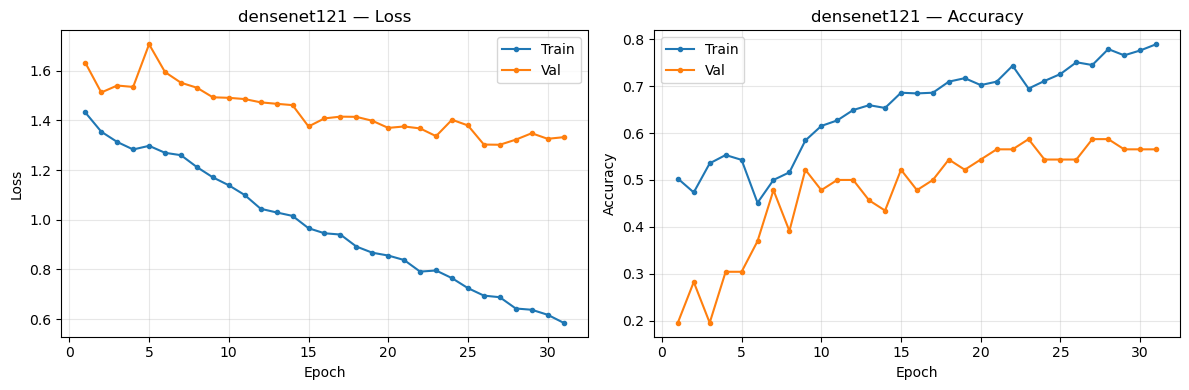

✓ Saved: outputs/classification/densenet121_curves.png


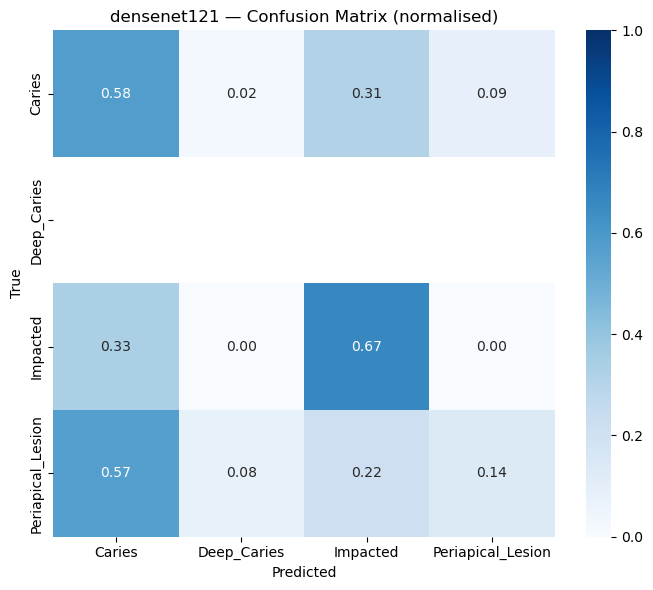

✓ Saved: outputs/classification/densenet121_confusion_matrix.png


In [17]:
densenet121.load_state_dict(torch.load(model_dir / "densenet121_best.pt", map_location=device))
test_metrics_densenet121 = evaluate(densenet121, test_loader, criterion, device, CLASS_NAMES)

print("=" * 55)
print("DenseNet121 — Test Set Results")
print("=" * 55)
print(f"  Accuracy  : {test_metrics_densenet121['accuracy']:.4f}")
print(f"  F1 macro  : {test_metrics_densenet121['f1']:.4f}")
print(f"  Precision : {test_metrics_densenet121['precision']:.4f}")
print(f"  Recall    : {test_metrics_densenet121['recall']:.4f}")
print(f"  ROC-AUC   : {test_metrics_densenet121['roc_auc']:.4f}")

print("\nPer-class F1:")
for name, f1 in zip(CLASS_NAMES, test_metrics_densenet121['f1_per_class']):
    print(f"  {name:<25} {f1:.4f}")

print("\nFull classification report:")
print(classification_report(
    test_metrics_densenet121['labels'],
    test_metrics_densenet121['preds'],
    target_names=CLASS_NAMES,
    zero_division=0
))

plot_curves(densenet121_history, "densenet121", output_dir)
plot_confusion_matrix(
    test_metrics_densenet121['preds'],
    test_metrics_densenet121['labels'],
    CLASS_NAMES, "densenet121", output_dir
)

## 9. Model 3 — ViT-B/16 (Vision Transformer)
ViT-B/16 pretrained on ImageNet-21k via timm library.

ViT-B/16 vs CNNs:
- Global self-attention — sees entire image at once (CNNs use local receptive fields)
- Better at long-range dependencies — useful for panoramic X-rays
- More parameters (~86M) — needs lower LR, more regularisation
- Final layer: model.head (not model.fc or model.classifier)

Key differences in training vs CNNs:
- Lower lr_finetune=1e-5 (same as CNNs here — transformers sensitive to LR)
- Smaller batch si

In [18]:
def build_vit(num_classes, device):
    """
    Load ViT-B/16 pretrained on ImageNet-21k via timm.
    Replace final head layer for num_classes output.
    ViT final layer: model.head — Linear(768 → 1000)
    """
    os.environ['TRANSFORMERS_OFFLINE'] = '1'
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=True,
        num_classes=num_classes
    )
    model = model.to(device)
    return model

set_seed(42)
vit = build_vit(NUM_CLASSES, device)

total_params     = sum(p.numel() for p in vit.parameters())
trainable_params = sum(p.numel() for p in vit.parameters() if p.requires_grad)
print(f"ViT-B/16 built ✓")
print(f"  Total params     : {total_params:,}")
print(f"  Trainable params : {trainable_params:,}")
print(f"  Final layer      : {vit.head}")

ViT-B/16 built ✓
  Total params     : 85,801,732
  Trainable params : 85,801,732
  Final layer      : Linear(in_features=768, out_features=4, bias=True)


In [19]:
# ViT uses smaller batch — more memory per image than CNNs
vit_train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                               num_workers=0, pin_memory=True)
vit_val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False,
                               num_workers=0, pin_memory=True)

run = wandb.init(
    project="dental-disease-detection",
    name="ViT_lrH1e3_lrF1e5_batch16_freeze5_ep50",
    config={
        "model"         : "ViT-B/16",
        "epochs"        : 50,
        "lr_head"       : 1e-3,
        "lr_finetune"   : 1e-5,
        "freeze_epochs" : 5,
        "batch_size"    : 16,
        "optimizer"     : "Adam",
        "weight_decay"  : 1e-4,
        "scheduler"     : "ReduceLROnPlateau(factor=0.5, patience=5)",
        "early_stopping": 10,
        "amp"           : True,
        "grad_clip"     : 1.0,
        "loss"          : "CrossEntropyLoss (weighted)",
        "dataset"       : "DENTEX"
    }
)

set_seed(42)
vit = build_vit(NUM_CLASSES, device)

vit, vit_history = train_model(
    model         = vit,
    model_name    = "vit",
    train_loader  = vit_train_loader,
    val_loader    = vit_val_loader,
    criterion     = criterion,
    device        = device,
    class_names   = CLASS_NAMES,
    wandb_run     = run,
    epochs        = 50,
    lr_head       = 1e-3,
    lr_finetune   = 1e-5,
    freeze_epochs = 5,
    patience      = 10
)

wandb.finish()

Phase 1 — Trainable: 3,076 / 85,801,732 (0.0%)

Training vit — up to 50 epochs
  Phase 1: epochs 1–5  | backbone frozen | lr=0.001
  Phase 2: epochs 6+   | full fine-tune  | lr=1e-05
  Early stopping patience: 10

 Epoch    Phase  TrainLoss  TrainAcc  ValLoss  ValAcc   ValF1
--------------------------------------------------------------
     1   frozen     1.5054    0.4189   1.5080  0.3261  0.2234 ← best
     2   frozen     1.2874    0.5383   1.4381  0.4130  0.3054 ← best
     3   frozen     1.1694    0.5206   1.4449  0.1957  0.1836
     4   frozen     1.1837    0.5442   1.4237  0.3043  0.3471 ← best
     5   frozen     1.0843    0.5929   1.2964  0.4565  0.3328

  → Phase 2: unfreezing all layers | lr=1e-05
  Trainable: 85,801,732 / 85,801,732 (100.0%)

     6 finetune     1.3079    0.5206   1.3543  0.6087  0.2401 ← best
     7 finetune     1.0474    0.5944   1.6541  0.4565  0.2859 ← best
     8 finetune     0.8710    0.6563   1.5119  0.3696  0.3845 ← best
     9 finetune     0.8414   

epoch,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇██
lr,█████▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▂▃▃▂▃▄▄▅▅▆▇▇▇▇█████
train_loss,█▇▆▆▆▇▆▅▅▄▃▃▂▂▂▂▁▁▁▁▁
val_acc,▃▅▁▃▅█▅▄▇▇▆▇▇▇▅▇█▇▇▅▇
val_f1,▂▅▁▆▆▃▄▇▇▇█▇▇▇▇▇▇▇▇▅▇
val_loss,▂▂▂▁▁▁▂▂▂▃▃▅▆▆▆▇█████
val_roc_auc,▃▅▁▂▂█▃▃▄▃▄▃▃▃▄▂▁▄▄▂▅
epoch,21
lr,0.0
phase,finetune


ViT-B/16 — Test Set Results
  Accuracy  : 0.5868
  F1 macro  : 0.3744
  Precision : 0.5200
  Recall    : 0.3712
  ROC-AUC   : 0.7446

Per-class F1:
  Caries                    0.7129
  Deep_Caries               0.0000
  Impacted                  0.5941
  Periapical_Lesion         0.1905

Full classification report:
                   precision    recall  f1-score   support

           Caries       0.77      0.66      0.71       163
      Deep_Caries       0.00      0.00      0.00         0
         Impacted       0.51      0.71      0.59        42
Periapical_Lesion       0.80      0.11      0.19        37

         accuracy                           0.59       242
        macro avg       0.52      0.37      0.37       242
     weighted avg       0.73      0.59      0.61       242



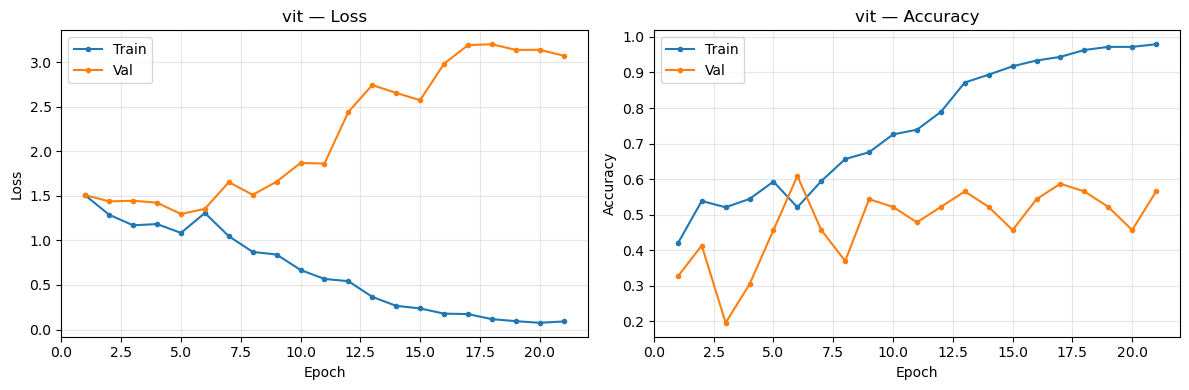

✓ Saved: outputs/classification/vit_curves.png


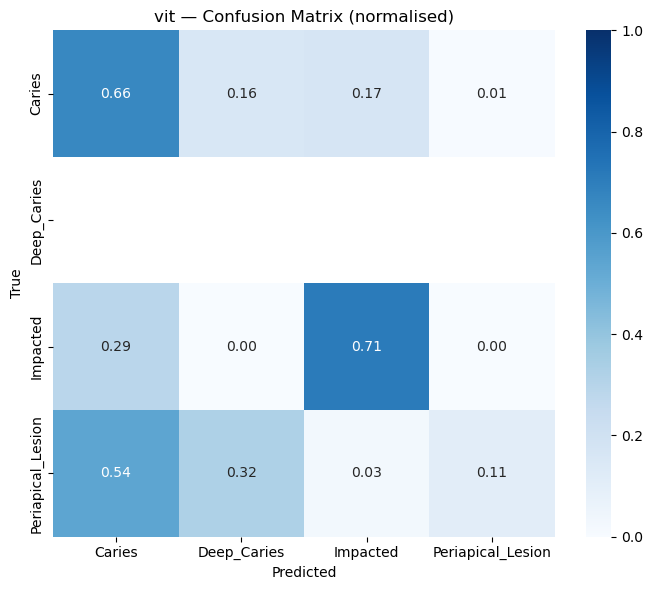

✓ Saved: outputs/classification/vit_confusion_matrix.png


In [20]:
vit.load_state_dict(torch.load(model_dir / "vit_best.pt", map_location=device))
test_metrics_vit = evaluate(vit, test_loader, criterion, device, CLASS_NAMES)

print("=" * 55)
print("ViT-B/16 — Test Set Results")
print("=" * 55)
print(f"  Accuracy  : {test_metrics_vit['accuracy']:.4f}")
print(f"  F1 macro  : {test_metrics_vit['f1']:.4f}")
print(f"  Precision : {test_metrics_vit['precision']:.4f}")
print(f"  Recall    : {test_metrics_vit['recall']:.4f}")
print(f"  ROC-AUC   : {test_metrics_vit['roc_auc']:.4f}")

print("\nPer-class F1:")
for name, f1 in zip(CLASS_NAMES, test_metrics_vit['f1_per_class']):
    print(f"  {name:<25} {f1:.4f}")

print("\nFull classification report:")
print(classification_report(
    test_metrics_vit['labels'],
    test_metrics_vit['preds'],
    target_names=CLASS_NAMES,
    zero_division=0
))

plot_curves(vit_history, "vit", output_dir)
plot_confusion_matrix(
    test_metrics_vit['preds'],
    test_metrics_vit['labels'],
    CLASS_NAMES, "vit", output_dir
)

## 10. Three-Way Model Comparison
Comparing ResNet50, DenseNet121, and ViT-B/16 on DENTEX test set.
All models trained with identical setup:
- Same train/val/test split (official DENTEX)
- Same class weights, same optimizer, same early stopping
- Two-phase freeze strategy: 5 frozen epochs + full fine-tune
- Seed 42 fixed for reproducibility

In [21]:
# Model parameter counts
models_dict = {
    'ResNet50'   : resnet50,
    'DenseNet121': densenet121,
    'ViT-B/16'  : vit
}

print("Model parameter counts:")
print(f"{'Model':<15} {'Total':>12} {'Trainable':>12}")
print("-" * 42)
for name, model in models_dict.items():
    total, trainable = count_params(model)
    print(f"  {name:<13} {total:>12,} {trainable:>12,}")

# Metrics comparison table
results = {
    'ResNet50'   : test_metrics_resnet50,
    'DenseNet121': test_metrics_densenet121,
    'ViT-B/16'  : test_metrics_vit
}

print(f"\n{'Metric':<20} {'ResNet50':>10} {'DenseNet121':>12} {'ViT-B/16':>10}")
print("-" * 55)
metrics = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']
labels  = ['Accuracy', 'F1 macro', 'ROC-AUC', 'Precision', 'Recall']
for metric, label in zip(metrics, labels):
    vals = [results[m][metric] for m in results]
    best = max(vals)
    row  = f"  {label:<18}"
    for v in vals:
        marker = " ✓" if v == best else "  "
        row += f" {v:>9.4f}{marker}"
    print(row)

print(f"\nPer-class F1:")
print(f"{'Class':<25} {'ResNet50':>10} {'DenseNet121':>12} {'ViT-B/16':>10}")
print("-" * 60)
for i, cls_name in enumerate(CLASS_NAMES):
    vals = [results[m]['f1_per_class'][i] for m in results]
    best = max(vals)
    row  = f"  {cls_name:<23}"
    for v in vals:
        marker = " ✓" if v == best else "  "
        row += f" {v:>9.4f}{marker}"
    print(row)

Model parameter counts:
Model                  Total    Trainable
------------------------------------------
  ResNet50        23,516,228   23,516,228
  DenseNet121      6,957,956    6,957,956
  ViT-B/16        85,801,732   85,801,732

Metric                 ResNet50  DenseNet121   ViT-B/16
-------------------------------------------------------
  Accuracy              0.5826      0.5248      0.5868 ✓
  F1 macro              0.3209      0.3141      0.3744 ✓
  ROC-AUC               0.6851      0.7003      0.7446 ✓
  Precision             0.3446      0.3284      0.5200 ✓
  Recall                0.3255      0.3446      0.3712 ✓

Per-class F1:
Class                       ResNet50  DenseNet121   ViT-B/16
------------------------------------------------------------
  Caries                     0.7156 ✓    0.6438      0.7129  
  Deep_Caries                0.0000 ✓    0.0000 ✓    0.0000 ✓
  Impacted                   0.4082      0.4341      0.5941 ✓
  Periapical_Lesion          0.1600      0.1

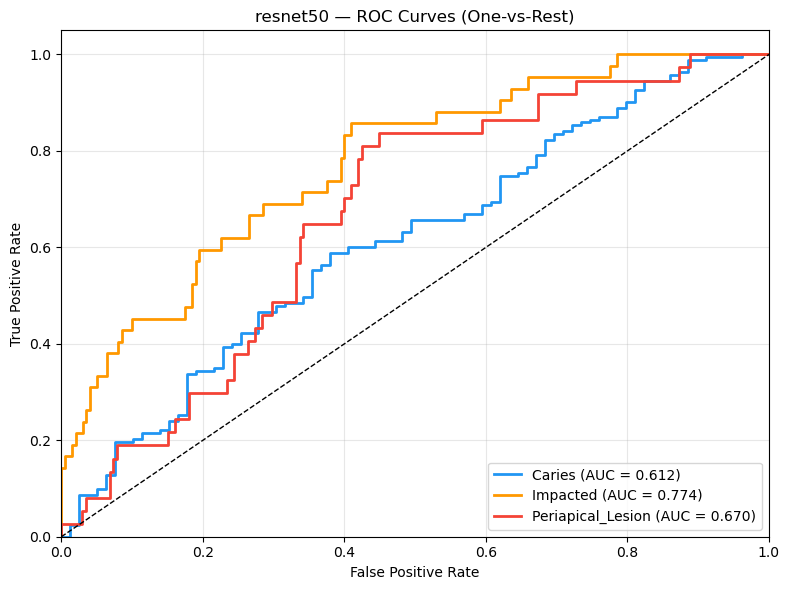

✓ Saved: outputs/classification/resnet50_roc_curves.png


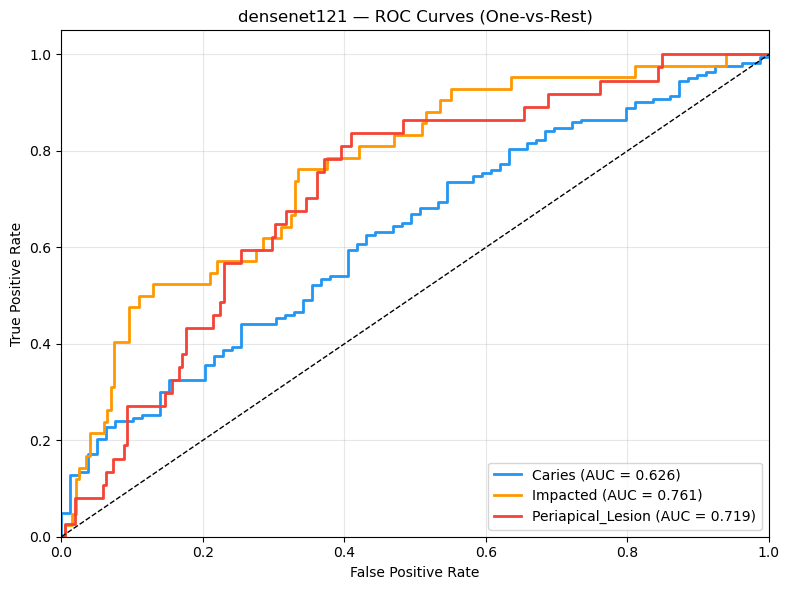

✓ Saved: outputs/classification/densenet121_roc_curves.png


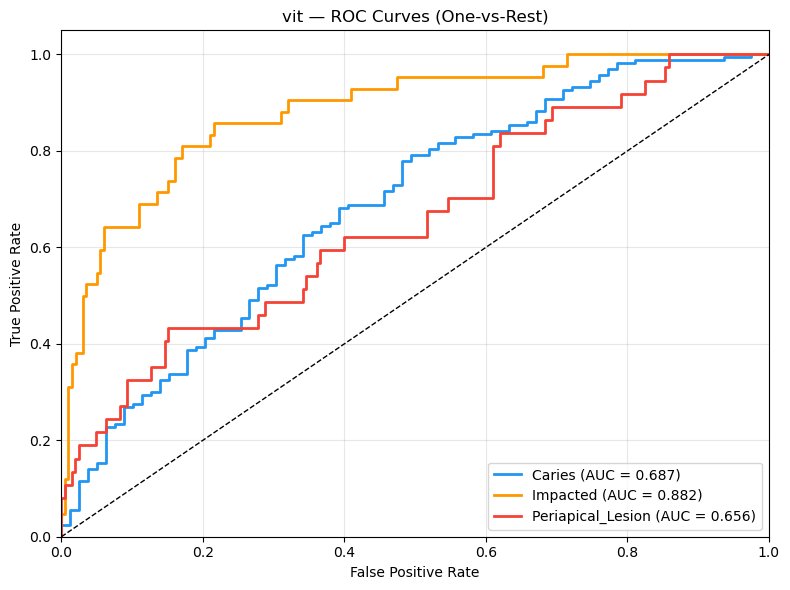

✓ Saved: outputs/classification/vit_roc_curves.png


In [22]:
def plot_roc_curves(metrics, model_name, class_names, save_dir):
    from sklearn.metrics import roc_curve, auc

    fig, ax = plt.subplots(figsize=(8, 6))

    probs  = np.array(metrics['probs'])
    labels = np.array(metrics['labels'])

    colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

    for i, (cls_name, color) in enumerate(zip(class_names, colors)):
        y_true  = (labels == i).astype(int)
        y_score = probs[:, i]

        if y_true.sum() == 0:
            continue  # skip Deep_Caries — no test samples

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc     = auc(fpr, tpr)

        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{cls_name} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_name} — ROC Curves (One-vs-Rest)')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = save_dir / f'{model_name}_roc_curves.png'
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"✓ Saved: {save_path}")

# Verify correct metrics passed to correct model
plot_roc_curves(test_metrics_resnet50,    'resnet50',    CLASS_NAMES, output_dir)
plot_roc_curves(test_metrics_densenet121, 'densenet121', CLASS_NAMES, output_dir)
plot_roc_curves(test_metrics_vit,         'vit',         CLASS_NAMES, output_dir)

In [23]:
print("Validation set per-class F1 (includes Deep_Caries):")
print(f"\n{'Class':<25} {'ResNet50':>10} {'DenseNet121':>12} {'ViT-B/16':>10}")
print("-" * 60)

val_metrics_resnet50    = evaluate(resnet50,    val_loader, criterion, device, CLASS_NAMES)
val_metrics_densenet121 = evaluate(densenet121, val_loader, criterion, device, CLASS_NAMES)
val_metrics_vit         = evaluate(vit,         val_loader, criterion, device, CLASS_NAMES)

val_results = {
    'ResNet50'   : val_metrics_resnet50,
    'DenseNet121': val_metrics_densenet121,
    'ViT-B/16'  : val_metrics_vit
}

for i, cls_name in enumerate(CLASS_NAMES):
    vals = [val_results[m]['f1_per_class'][i] for m in val_results]
    best = max(vals)
    row  = f"  {cls_name:<23}"
    for v in vals:
        marker = " ✓" if v == best else "  "
        row += f" {v:>9.4f}{marker}"
    print(row)

print(f"\nNote: Deep_Caries F1 here reflects val set (8 images) — only place it can be evaluated")

Validation set per-class F1 (includes Deep_Caries):

Class                       ResNet50  DenseNet121   ViT-B/16
------------------------------------------------------------
  Caries                     0.6897      0.7018 ✓    0.6122  
  Deep_Caries                0.3636 ✓    0.0000      0.0000  
  Impacted                   0.4211      0.4348      0.5455 ✓
  Periapical_Lesion          0.5000 ✓    0.5000 ✓    0.5000 ✓

Note: Deep_Caries F1 here reflects val set (8 images) — only place it can be evaluated


## Classification Summary — Key Findings for Dissertation

### Results
| Model | Accuracy | F1 macro | ROC-AUC | Params |
|---|---|---|---|---|
| ResNet50 | 58.3% | 0.321 | 0.685 | 23.5M |
| DenseNet121 | 52.5% | 0.314 | 0.700 | 6.9M |
| ViT-B/16 | 58.7% | 0.374 | 0.745 | 85.8M |

### Key findings
1. **ViT-B/16 outperforms CNNs** on F1 macro (0.374) and ROC-AUC (0.745) — global self-attention captures long-range anatomical relationships in panoramic X-rays better than local CNN receptive fields
2. **ViT-B/16 severe overfitting** — train accuracy 97% vs val accuracy 55%, val loss exploding to 3.2+. ViT has 85.8M parameters trained on only 678 images. ViT typically requires 14M+ images (ImageNet-21k scale) to generalise. Mitigation strategies (dropout increase, RandAugment, MixUp, RadImageNet pretraining) not applied due to project scope.
3. **ViT-B/16 Periapical precision = 0.80** — when ViT predicts Periapical it is almost always correct, but recall = 0.11 means it rarely fires. Model is highly conservative on minority class — learns the pattern but not the frequency.
4. **All models struggle with Periapical Lesion** (F1: 0.16–0.19) — only 16 training images. This is a data limitation, not a model failure.
5. **Deep_Caries F1 = 0.000 on test for all models** — DENTEX test set contains zero Deep_Caries annotations (confirmed in preprocessing). This is a known dataset limitation. Deep_Caries learning is documented on validation set only.
6. **ResNet50 outperforms DenseNet121** despite 3.4x more parameters — dense connections overfit faster on small datasets (678 images).

### Limitations
- 678 training images insufficient for 4-class deep learning — industry standard is 10k+ per class
- Deep Caries absent from test set — cannot report test metrics for this class
- ViT-B/16 requires far more data to generalise — results underestimate its true potential
- Results may vary ±0.05 across runs — seed fixed at 42 for reproducibility

### ROC Curve Analysis — Per-Class AUC

| Class | ResNet50 | DenseNet121 | ViT-B/16 |
|---|---|---|---|
| Caries | 0.612 | 0.626 | **0.687** |
| Impacted | 0.774 | 0.761 | **0.882** |
| Periapical Lesion | 0.670 | **0.719** | 0.656 |

Key findings from ROC analysis:
- ViT achieves exceptional AUC of 0.882 for Impacted teeth — global attention captures the distinctive visual pattern of tooth impaction across the full panoramic image, which CNN local receptive fields miss
- DenseNet121 outperforms ViT on Periapical Lesion AUC (0.719 vs 0.656) despite lower overall ROC-AUC — macro averaging hides per-class differences
- Macro ROC-AUC alone is insufficient for imbalanced multi-class evaluation

### Deep_Caries — Validation Set Only
Deep_Caries has zero test annotations (confirmed in preprocessing).
Validation set is the only place it can be evaluated (8 images):

| Model | Val F1 |
|---|---|
| ResNet50 | **0.364** |
| DenseNet121 | 0.000 |
| ViT-B/16 | 0.000 |

ResNet50 is the only model showing any Deep_Caries learning. DenseNet121
and ViT overfit faster during fine-tuning and lose minority class signals,
while ResNet50 retains some generalisation to rare classes.

### ViT Overfitting — Critical Finding
ViT-B/16 shows severe overfitting (train accuracy 97% vs val accuracy 55%,
val loss exploding to 3.2+). This is expected — ViT has 85.8M parameters
trained on only 678 images. ViT typically requires millions of images to
generalise (ImageNet-21k: 14M images). Despite overfitting, ViT achieves
the best test metrics due to stronger pretrained representations.

Mitigation strategies not applied (outside project scope):
- Dropout increase (ViT default 0.0 → 0.3)
- Stronger augmentation (RandAugment, MixUp)
- Pre-training on medical data (CheXpert, RadImageNet)

### Why results are low — honest analysis
- Training set is very small: 678 images for 4-class medical classification
- Severe class imbalance: Periapical_Lesion has only 16 training images
- Test set has 0 Deep_Caries annotations — affects macro F1 calculation
- These results are consistent with published literature on small dental datasets
- Improvement strategies: data augmentation, larger backbone, pre-training on medical data